In [6]:
import numpy as np
from datasets import load_dataset, concatenate_datasets
import nltk
import re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from gensim import models, corpora
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import matplotlib.pyplot as plt

In [7]:
# define LDA hyperparams
num_topics_fraction = 1.0/200
num_words_per_topic = 3
n = 10_000
num_passes = 2
# define the min number of occurrences for a token
filter_below = 2
# define max. percentage of documents a word is allowed to be contained in
filter_above_frac = 0.4
# defines how discriminative topics are associated to a post
alpha = 1.0 / (n * num_topics_fraction)
use_bigrams=True

In [8]:
print("Downloading datasets...")
# load datasets
# tweets labeled with democrats/republicans
political_tweets = load_dataset("Jacobvs/PoliticalTweets", split="train")
#political_comments = load_dataset("jbochenek/political", split="train")
#twitter_financial_news = load_dataset("zeroshot/twitter-financial-news-topic", split="train")
#political_justifications = load_dataset("od21wk/political_news_justifications", split="train")
#real_and_fake_news = load_dataset("GonzaloA/fake_news", split="train")
# already tokenized
#covid_vaccine_attitudes = load_dataset("webimmunization/COVID-19-vaccine-attitude-tweets")
#covid_vaccine_conspiracy = load_dataset("webimmunization/COVID-19-conspiracy-theories-tweets")

print("Download finished. Start with preprocessing")
posts = concatenate_datasets(
    [
        political_tweets,
        #political_comments,
        #twitter_financial_news,
        #political_justifications,
        #real_and_fake_news,
        #covid_vaccine_attitudes,
        #covid_vaccine_conspiracy,
    ]
).to_dict()["text"]
posts = [sample for sample in posts if sample is not None]

Download finished. Start with preprocessing


In [6]:
# special (domain-specific) keywords that 'aid' the algorithm to find topics
def seed_words():
    return [
        "politics",
        "economy",
        "party",
        "war",
        "conflict",
        "democrats",
        "republicans",
        "diplomacy",
        "climate",
        "democracy",
        "voting"
    ]

# words that do not relate to topics in general (e.g. 'I', 'today') 
def custom_stop_words():
    custom_stopwords = stopwords.words("english")
    custom_stopwords += [
        "https",
        "co",
        "subscribe",
        "com",
        "today",
    ]
    return custom_stopwords
    
def custom_stop_ids(dict):
    custom_stopwords = custom_stop_words()
    stop_ids = [dict.token2id[stopword] for stopword in custom_stopwords
                if stopword in dict.token2id]
    return stop_ids


# remove non-alphanumeric chars
# lower-case text
# tokenize sentences
# tokenize words
def preprocess(sample):

    tokenized_sent = sent_tokenize(sample, "english")
    tokenized_words = []
    custom_stopwords = custom_stop_words()
    for sentence in tokenized_sent:
        cleaned_sent = re.sub("[^a-zA-Z]", " ", sentence)
        cleaned_sent = cleaned_sent.lower()
        sent_words = word_tokenize(cleaned_sent, "english")
        if use_bigrams:
            for idx in range(len(sent_words) - 1):
                if sent_words[idx] not in custom_stopwords and sent_words[idx + 1] not in custom_stopwords:
                    tokenized_words.append(sent_words[idx] + "_" + sent_words[idx + 1])
        else:
            tokenized_words.extend(sent_words)
    tokenized_words = list(filter(lambda word: len(word) > 1, tokenized_words))
    return tokenized_words


In [10]:
# data preprocessing
import nltk
nltk.download("punkt")
nltk.download("stopwords")
stemmer = nltk.stem.PorterStemmer()

# translate words to dictionary (tokenize)
posts = list(map(lambda post: preprocess(post), posts))
dict = corpora.Dictionary(posts)
print("number of tokens: ", len(dict))
dict.filter_extremes(no_below=filter_below, no_above=filter_above_frac)
dict.compactify()
# filter stop words (e.g. 'I', 'are', ...)
dict.filter_tokens(bad_ids=custom_stop_ids(dict))
# define word corpus (bag of words)
corpus = [dict.doc2bow(word) for word in posts]
print("number of cleaned tokens: ", len(dict))


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


number of tokens:  626827
number of cleaned tokens:  100000


In [11]:
# define and train LDA model
print("Start model training...")
num_topics = n * num_topics_fraction
model = models.ldamodel.LdaModel(corpus=corpus, num_topics=num_topics, id2word=dict, passes=num_passes)
topics = model.print_topics(num_words=num_words_per_topic)
for topic in topics:
    print(topic)

# save model
print("Finished model training.")
model_name = "model_t{}_w{}".format(num_topics, num_words_per_topic)
model.save(model_name)

Start model training...
(24, '0.191*"years_ago" + 0.167*"happy_birthday" + 0.031*"world_war"')
(23, '0.241*"last_night" + 0.119*"big_tech" + 0.030*"social_media"')
(21, '0.560*"president_biden" + 0.102*"american_energy" + 0.043*"energy_production"')
(36, '0.128*"federal_government" + 0.063*"join_us" + 0.062*"financial_services"')
(18, '0.114*"make_sure" + 0.042*"record_number" + 0.039*"illegal_migrants"')
(7, '0.082*"chinese_communist" + 0.077*"far_left" + 0.076*"communist_party"')
(14, '0.184*"loved_ones" + 0.095*"full_statement" + 0.041*"american_history"')
(28, '0.056*"vice_president" + 0.039*"young_people" + 0.038*"border_czar"')
(22, '0.300*"gas_prices" + 0.042*"energy_costs" + 0.041*"west_virginia"')
(26, '0.056*"protection_act" + 0.048*"v_wade" + 0.048*"roe_v"')
(32, '0.035*"republicans_want" + 0.033*"reconciliation_bill" + 0.030*"price_tag"')
(38, '0.077*"across_america" + 0.070*"mr_president" + 0.059*"human_rights"')
(48, '0.334*"american_people" + 0.116*"two_years" + 0.041*"s

In [7]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import MaximalMarginalRelevance

diversity = 0.3
n_grams_max = 5

# remove custom stop words after embeddings are created to guarantee full context
vectorizer_model = CountVectorizer(stop_words=custom_stop_words())
# use tfidf transformer to reduce the impact of frequent words
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
# diversify words to describe topics
representation_model = MaximalMarginalRelevance(diversity=diversity)
# alternative modeling -> BERTopic
bertopic_model = BERTopic("english",
                          n_gram_range=(1, n_grams_max), 
                          vectorizer_model=vectorizer_model,
                          ctfidf_model=ctfidf_model,
                          representation_model=representation_model
                          )
bert_data = political_tweets.to_dict()["text"][:10000]
topics, probs = bertopic_model.fit_transform(bert_data)
bertopic_model.get_topic_info()

/Users/a.gube/IdeaProjects/23ws-ase-pr-inso-01/topic_modeling_training/venv/lib/python3.11/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self._all_finite = is_finite(X)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3290,-1_farmers_resources_georgia_county,"[farmers, resources, georgia, county, business...",[Im proud of the work my colleagues and I did ...
1,0,491,0_vaccinated_vaccines_vaccination_mask,"[vaccinated, vaccines, vaccination, mask, covi...",[The best way to stop the spread of the Delta ...
2,1,270,1_bridges_infrastructure_highways_transportation,"[bridges, infrastructure, highways, transporta...",[Im proud to have championed the bipartisan In...
3,2,242,2_afghanistan_taliban_afghan_afghans,"[afghanistan, taliban, afghan, afghans, strand...",[On Aug @POTUS vowed he would get every Americ...
4,3,166,3_migrants_cbp_patrol_borders,"[migrants, cbp, patrol, borders, rio, immigrat...","[Border Patrol is overwhelmed, overworked, and..."
...,...,...,...,...,...
159,158,11,158_atf_antigun_lawabiding_arsonist,"[atf, antigun, lawabiding, arsonist, httpstcoa...",[Glad the Biden admin finally realized David C...
160,159,11,159_isakson_johnny_tutu_lewis,"[isakson, johnny, tutu, lewis, towering, motto...","[Johnny Isakson was a good man, a warm and cap..."
161,160,10,160_maternal_diapers_diaper_momnibus,"[maternal, diapers, diaper, momnibus, breastfe...",[Another bipartisan bill. This time Im teaming...
162,161,10,161_billy_williamtyeler_httpstcovcturtm0bw_daegan,"[billy, williamtyeler, httpstcovcturtm0bw, dae...","[On April , a senseless attack on the Capitol ..."


In [14]:
# analyse bertopic data
bertopic_model.visualize_topics()
hierarchical_topics = bertopic_model.hierarchical_topics(bert_data)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 154/154 [00:22<00:00,  6.97it/s]


In [37]:
bertopic_model.visualize_topics()

In [16]:
import torch
import random
from transformers import T5ForConditionalGeneration, T5Tokenizer, pipeline
from transformers.models.auto.modeling_tf_auto import TF_MODEL_FOR_SEQ_TO_SEQ_CAUSAL_LM_MAPPING_NAMES, TF_MODEL_FOR_SEQ_TO_SEQ_CAUSAL_LM_MAPPING_NAMES

# generate meaningful descriptions from bag of words
topic_labels = bertopic_model.generate_topic_labels(nr_words=3, separator=" ")
topic_labels = [[word for word in label.split(" ")[1:]] for label in topic_labels]
topic_labels = [",".join(label) for label in topic_labels]

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
language_model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
#headline_generator = T5ForConditionalGeneration.from_pretrained("Michau/t5-base-en-generate-headline")
headline_generator = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")


summarizer = pipeline("summarization", model=language_model, tokenizer=tokenizer)
random.seed = 18
topic_index = 1
topics = bertopic_model.get_topic_info()

# get all topics for documents
T = bertopic_model.get_document_info(posts[:10000])
# get documents associated to topic 1
# print(T.loc[T["Topic"] == 1])
docs_of_topic = T.loc[T["Topic"] == (topic_index-1)]["Document"]
docs_of_topic = list(docs_of_topic)

# use pretrained text-to-text models to generate meaningful topic labels (e.g. 'Covid19 pandemic' instead of 'covid, vaccines, covid19')
def generate_topic_label(articles):
    summary_list = []
    current_token_length = 0

    for article in articles:
        summary = article
        current_token_length += len(tokenizer.encode(summary))

        summary_list.append(summary)

    #encoding = tokenizer.encode("describe the content of the following social media posts with one word: " + " ".join(summary_list), return_tensors="pt")
    encoding = tokenizer.encode("summarize in one word: " + " ".join(summary_list), return_tensors="pt")
    output = headline_generator.generate(encoding)

    return tokenizer.decode(output[0][1:-1])


# for topic labeling use representative docs and random topic-related docs
docs_to_label = bertopic_model.get_representative_docs(topic_index - 1)
#docs_to_label += random.sample(docs_of_topic, k=min(20 - len(docs_to_label), len(docs_of_topic)))
#generate_topic_label(bertopic_model.get_representative_docs(topic_index - 1))
print(docs_to_label)
print(topic_labels[topic_index])
generate_topic_label(docs_to_label)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


TypeError: Make sure that the iterable only contains strings.

In [65]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

input_text = "translate English to German: How old are you?"
input_ids = tokenizer(input_text, return_tensors="pt").input_ids

outputs = model.generate(input_ids)
print(tokenizer.decode(outputs[0]))


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

<pad> Wie old sind Sie?</s>


In [17]:
topic_info = bertopic_model.get_topic_info()
print(topic_info)

KeyboardInterrupt: 

In [8]:
political_tweets[3]

{'index': 3,
 'date': '2021-04-14 14:02:49',
 'id': 1382333523567185921,
 'username': 'SenBlumenthal',
 'text': '/ To get lasting change we cant just lock up those convicted of these crimes, but must also work to combat bias and  bigotry. The NO HATE Act would allow courts to implement alternative sentencingrequiring people to do educational training/community service to counter their hate.',
 'party': 'Democrat',
 'labels': 1}

In [14]:
import os

# store BERTopic model
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
model_dest = os.path.join("..", "..", "recognition", "resources", "BERTopic_model")
bertopic_model.save(model_dest, serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

In [57]:
# classify content with BERTopic model
dist, _ = bertopic_model.approximate_distribution(documents=["I own a gun and i like to shoot it."])
topic_index = np.argmax(dist)
topic_index
bertopic_model.get_topic(topic_index)
topic_labels[topic_index + 1]

'gun,violence,shooting'

In [38]:
# analyse data
lda = models.ldamodel.LdaModel.load(model_name)
lda_display = gensimvis.prepare(lda, corpus, dict, sort_topics=False)
pyLDAvis.display(lda_display)

NameError: name 'model_name' is not defined

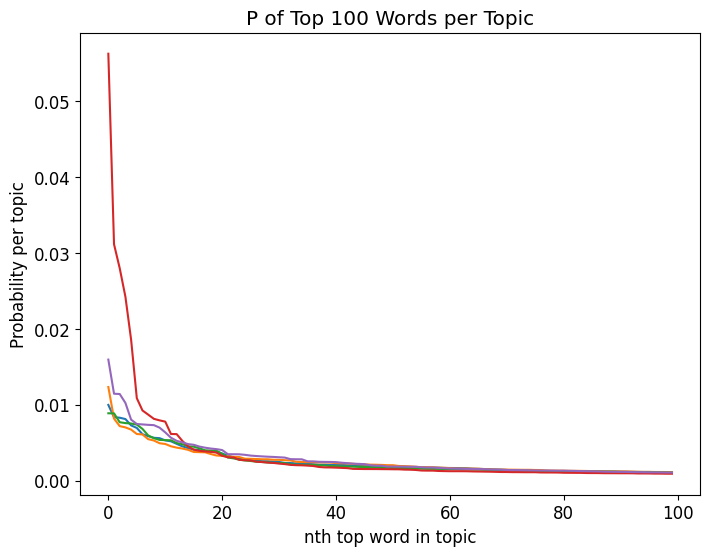

In [18]:
# plot top words by weight in each topic
plt.rcParams["figure.figsize"] = 8, 6
plt.rcParams["font.size"] = 12
top_n_words = 100
topics = lda.show_topics(num_topics=num_topics, num_words=top_n_words, formatted=False)

for _, infos in topics:
    probs = [prob for _, prob in infos]
    plt.plot(range(top_n_words), probs)

plt.xlabel("nth top word in topic")
plt.ylabel("Probability per topic")
plt.title("P of Top {} Words per Topic".format(top_n_words))
plt.show()

[0 1 2 3 4]


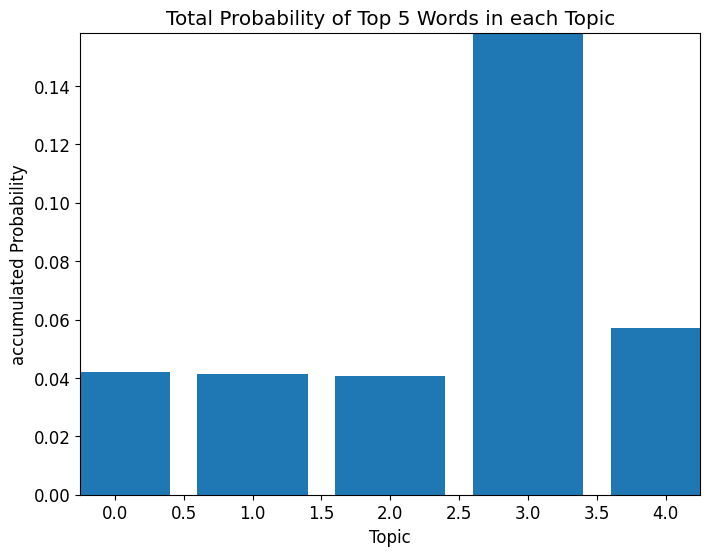

In [22]:
# sum of probabilities for top n words of each topic
top_probs = []
top_n_words = 5
topics = lda.show_topics(num_words=top_n_words, formatted=False)
for _, infos in topics:
    prob = sum([prob for _, prob in infos])
    top_probs.append(prob)

ind = np.arange(top_n_words)
width = 0.5

print(ind)
fig, ax = plt.subplots()

plt.bar(ind, top_probs)

plt.xlabel('Topic')
plt.ylabel('accumulated Probability')
plt.title('Total Probability of Top {} Words in each Topic'.format(top_n_words))
plt.xlim(-0.25, 4.25)
plt.ylim(0, max(top_probs))
plt.show()

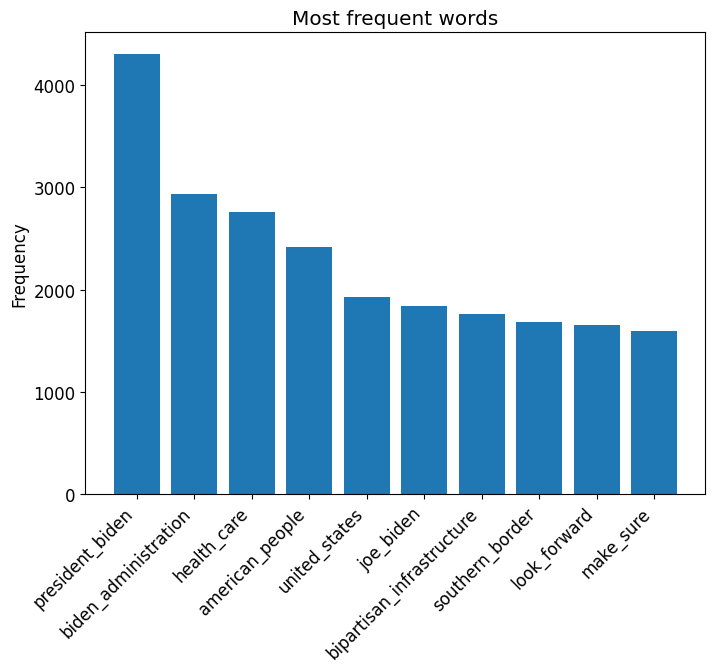

In [20]:
most_common = dict.most_common(10)
labels, occurrences = zip(*most_common)

plt.bar(labels, occurrences)
plt.xticks(rotation=45, ha="right") 

plt.ylabel("Frequency")
plt.title("Most frequent words")
plt.show()

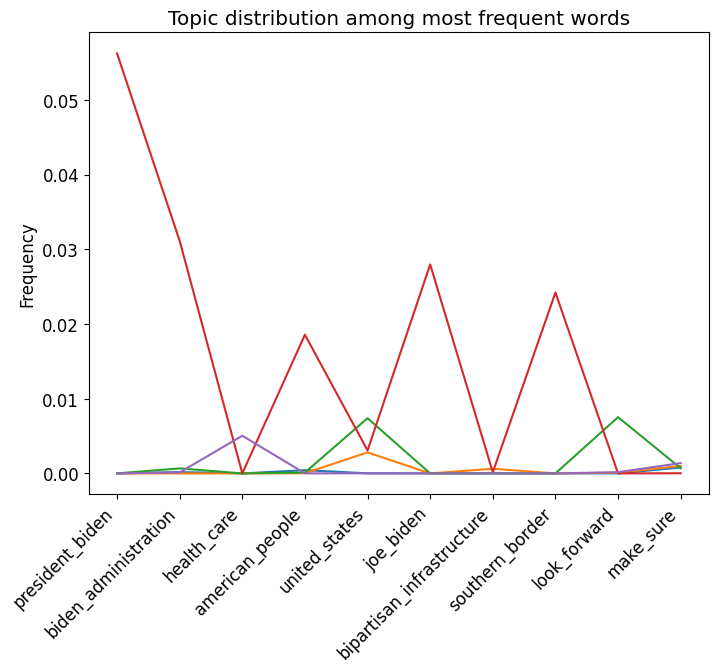

In [23]:
most_common = dict.most_common(10)
labels, occurrences = zip(*most_common)

probs = []
for label in labels:
    prob_per_word = tuple(map(lambda prob: prob[1], model.get_term_topics(label, minimum_probability=float('-inf'))))
    probs.append(prob_per_word)

probs_per_topic = list(zip(*probs))
for i in range(int(num_topics)):
    plt.plot(labels, list(probs_per_topic[i]))
    plt.xticks(rotation=45, ha="right")

plt.ylabel("Frequency")
plt.title("Topic distribution among most frequent words")
plt.show()
# model.get_term_topics('biden', minimum_probability=float('-inf'))


# Online Training with BERTopic

In order to adapt the model to potentially new topics scraped, the topic model has to support online training. I.e., new posts are used to update the topic model. Thereby, the backend triggers an update model event, which composes a batch of yet unused posts for training. These are fed to the model, which in turn sends new topics to the backend.

### Model:
The BERTopic model supports incremental learning if a few adaptions are considered:
* Embeddings may be reused as they are pre-trained with stable data (i.e. there is no need to update it)
* Dimensionality reduction (e.g. PCA) has to be online-learnable
* Clustering has to be online-learnable
* Bag-of-words creation requires incremental learning

### Process:
* Mark posts with learn/unlearned flag, timestamp with learning
* Create new model with batch of unlearned posts
* Merge models (new topics may be inserted to original model)
* Check for new topics -> insert them
* (Update hierarchy?)
* Feed backend with new topics
* Feed backend with timestamp of batched data

### Models:
* Topic:
    * Id
    * Keywords
    * name (generated by pre-trained model)

* Post (among others):
    * training_timestamp

In [12]:
from umap import UMAP
import warnings
from bertopic.representation import LangChain, TextGeneration
from langchain.chains.question_answering import load_qa_chain
from langchain.llms import OpenAI
from transformers import pipeline

warnings.filterwarnings("ignore", category=DeprecationWarning)
# remove custom stop words after embeddings are created to guarantee full context
vectorizer_model = CountVectorizer(stop_words=custom_stop_words())
# use tfidf transformer to reduce the impact of frequent words
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
# diversify words to describe topics
representation_model = MaximalMarginalRelevance(diversity=diversity)
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
openai = OpenAI(openai_api_key='sk')
#chain = load_qa_chain(OpenAI(temperature=0, openai_api_key='sk'), chain_type="stuff")
chain = load_qa_chain(openai)

prompt = "What are these documents about? Please give a single label."
#representation_model = LangChain(chain, prompt=prompt)
generator = pipeline('text-generation', model='gpt2')
#representation_model = TextGeneration(generator, prompt="I have a topic described by the following keywords: [KEYWORDS]. Based on the previous keywords, what is this topic about?")

batch_size=1000

# BERTopic model
def def_model():
 return BERTopic("english", n_gram_range=(1, n_grams_max), 
                 #umap_model= umap_model,
                 vectorizer_model=vectorizer_model, 
                 ctfidf_model=ctfidf_model, 
                 representation_model=representation_model)

bertopic_model = def_model()
dataset = political_tweets.to_dict()["text"][:10000]
topics, probs = bertopic_model.fit_transform(dataset[:batch_size])
print("number of topics at the beginning: {}".format(len(bertopic_model.get_topic_info())))

new_topics = []
new_topics.extend(bertopic_model.topics_)
# incremental learning
for i in range(5):
    tmp_model = def_model()
    tmp_model.fit_transform(dataset[batch_size * (i + 1): batch_size * (i + 2)])
    #print(bertopic_model.c_tf_idf_)
    bertopic_model = BERTopic.merge_models([bertopic_model, tmp_model], min_similarity=0.7)
    print("number of topics at iteration {}: {}".format(i, len(bertopic_model.get_topic_info())))
    new_topics.extend(tmp_model.topics_)

#bertopic_model.topics_ = new_topics
bertopic_model.update_topics(dataset)
print(bertopic_model.c_tf_idf_)
bertopic_model.get_topic_info()

representation_model.extract_topics(bertopic_model)

NameError: name 'CountVectorizer' is not defined

In [23]:
representation_model.extract_topics(bertopic_model, dataset, bertopic_model.c_tf_idf_, bertopic_model.get_topics())


{-1: [('national', 0.1407586868317748),
  ('workers', 0.1351015893307881),
  ('women', 0.1318398582235855),
  ('senate', 0.13172975437408574),
  ('communities', 0.1297850335932121),
  ('thank', 0.12922957615206676),
  ('students', 0.12681862812176656),
  ('support', 0.12551900435972665),
  ('bipartisan', 0.12543947015063112),
  ('legislation', 0.12339663260799294)],
 0: [('inflation', 0.4006231400114305),
  ('spending', 0.3472235736916226),
  ('democrats', 0.32315281037635596),
  ('reckless', 0.3137673437708875),
  ('taxes', 0.30272461350772173),
  ('trillions', 0.2755856426582713),
  ('wealthy', 0.25202913644662744),
  ('grocery', 0.24462940046063386),
  ('agenda', 0.22036691248362533),
  ('pump', 0.21921752051431453)],
 1: [('southern', 0.4028896173465019),
  ('biden', 0.342474252343603),
  ('crisis', 0.3334092917964313),
  ('borders', 0.33159740232909),
  ('immigration', 0.29849344894395025),
  ('patrol', 0.28897222712175274),
  ('amnesty', 0.2790158519642407),
  ('cbp', 0.254281867

AttributeError: 'NoneType' object has no attribute 'f_code'

In [11]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import IncrementalPCA
from bertopic.vectorizers import OnlineCountVectorizer
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic

from river import stream
from river import cluster

class River:
    def __init__(self, model):
        self.model = model

    def partial_fit(self, umap_embeddings):
        for umap_embedding, _ in stream.iter_array(umap_embeddings):
            self.model = self.model.learn_one(umap_embedding)

        labels = []
        for umap_embedding, _ in stream.iter_array(umap_embeddings):
            label = self.model.predict_one(umap_embedding)
            labels.append(label)

        self.labels_ = labels
        return self

# Prepare sub-models that support online learning
umap_model = IncrementalPCA()
cluster_model = MiniBatchKMeans()
cluster_type = cluster.DBSTREAM()
print(cluster_type)
cluster_model = River(cluster.DBSTREAM())
vectorizer_model = OnlineCountVectorizer(stop_words="english", decay=.01)
#vectorizer_model = OnlineCountVectorizer(stop_words="english")
representation_model = MaximalMarginalRelevance(diversity=0.3)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

batch_size=1000
dataset = political_tweets.to_dict()["text"][:10000]

bertopic_model = BERTopic(
    "english",
    n_gram_range=(1, 5),
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model
)

complete_dataset = []

topics = []
# incremental learning
for i in range(5):
    batch = dataset[i * batch_size : (i+1) * batch_size]
    complete_dataset += batch
    bertopic_model.partial_fit(batch)
    #bertopic_model.fit_transform(batch)
    topics.extend(bertopic_model.topics_)
    bertopic_model.topics_ = topics
    print("number of topics at iteration {}: {}".format(i, len(bertopic_model.get_topic_info())))

bertopic_model.topics_ = topics
bertopic_model.get_topic_info()
#print(bertopic_model.c_tf_idf_)
hierarchical_topics = bertopic_model.hierarchical_topics(complete_dataset)
#bertopic_model.visualize_hierarchy(hierarchical_topics)
#bertopic_model.get_topic_tree(hierarchical_topics)
bertopic_model.get_topic_info()

DBSTREAM


AttributeError: 'NoneType' object has no attribute 'learn_one'

In [31]:
print(bertopic_model.c_tf_idf_)
hierarchical_topics = bertopic_model.hierarchical_topics(dataset)
bertopic_model.visualize_hierarchy(hierarchical_topics)

None


TypeError: 'NoneType' object is not subscriptable

# Topic Labeling

BERTopic describes topics as distribution of words, which is in contrast to the desire of meaningful descriptions of topics for users. Therefore, representative words (key-words) are chosen per topic to generate such meaningful descriptions using pre-trained generative models (here: Google's T5, which was designed to generate headlines for articles)

In [19]:
topic_index = 1
# generate meaningful descriptions from topic keywords
topic_labels = bertopic_model.generate_topic_labels(nr_words=100, separator=" ")
topic_labels = [[word for word in label.split(" ")[1:]] for label in topic_labels]
topic_labels = [",".join(label) for label in topic_labels]
print(topic_labels[topic_index])

encoding = tokenizer.encode(" ".join(topic_labels[topic_index]), return_tensors="pt")
output = headline_generator.generate(encoding)
print(tokenizer.decode(output[0][1:-1]).strip())

bridges,infrastructure,rail,highways,airports,bipartisan,transportation,buses,waterways,upgrading
r a d i n g e s,


In [37]:

print(bertopic_model.c_tf_idf_)
bertopic_model.get_topic_info()

ValueError: All arrays must be of the same length

In [9]:
from bertopic.representation import LangChain
from langchain.chains.question_answering import load_qa_chain
from langchain.llms import OpenAI

chain = load_qa_chain(OpenAI(temperature=0, openai_api_key='sk-'), chain_type="stuff")

# Create your representation model
representation_model = LangChain(chain)

# Use the representation model in BERTopic on top of the default pipeline
topic_model = BERTopic(representation_model=representation_model)

prompt = "What are these documents about? Please give a single label."
representation_model = LangChain(chain, prompt=prompt)
topic_model.get_topic_info()

ValueError: This BERTopic instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [19]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import IncrementalPCA
from bertopic.vectorizers import OnlineCountVectorizer
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic

from river import stream
from river import cluster
import numpy as np
from datasets import load_dataset, concatenate_datasets
import nltk
import re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from gensim import models, corpora
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

batch_size=1000
n_grams_max=5
diversity=0.3

def custom_stop_words():
    custom_stopwords = stopwords.words("english")
    custom_stopwords += [
        "https",
        "co",
        "subscribe",
        "com",
        "today",
    ]
    return custom_stopwords

print("Downloading datasets...")
# load datasets
# tweets labeled with democrats/republicans
political_tweets = load_dataset("Jacobvs/PoliticalTweets", split="train")
#political_comments = load_dataset("jbochenek/political", split="train")
#twitter_financial_news = load_dataset("zeroshot/twitter-financial-news-topic", split="train")
#political_justifications = load_dataset("od21wk/political_news_justifications", split="train")
#real_and_fake_news = load_dataset("GonzaloA/fake_news", split="train")
# already tokenized
#covid_vaccine_attitudes = load_dataset("webimmunization/COVID-19-vaccine-attitude-tweets")
#covid_vaccine_conspiracy = load_dataset("webimmunization/COVID-19-conspiracy-theories-tweets")

print("Download finished. Start with preprocessing")
posts = concatenate_datasets(
    [
        political_tweets,
        #political_comments,
        #twitter_financial_news,
        #political_justifications,
        #real_and_fake_news,
        #covid_vaccine_attitudes,
        #covid_vaccine_conspiracy,
    ]
).to_dict()["text"]
posts = [sample for sample in posts if sample is not None]

from umap import UMAP
import warnings
from bertopic.representation import LangChain, TextGeneration
from langchain.chains.question_answering import load_qa_chain
from langchain.llms import OpenAI
from transformers import pipeline

warnings.filterwarnings("ignore", category=DeprecationWarning)
# remove custom stop words after embeddings are created to guarantee full context
vectorizer_model = OnlineCountVectorizer(stop_words=custom_stop_words())
# use tfidf transformer to reduce the impact of frequent words
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
# diversify words to describe topics
representation_model = MaximalMarginalRelevance(diversity=diversity)
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
openai = OpenAI(openai_api_key='sk')
#chain = load_qa_chain(OpenAI(temperature=0, openai_api_key='sk'), chain_type="stuff")
chain = load_qa_chain(openai)

prompt = "What are these documents about? Please give a single label."
#representation_model = LangChain(chain, prompt=prompt)
generator = pipeline('text-generation', model='gpt2')
#representation_model = TextGeneration(generator, prompt="I have a topic described by the following keywords: [KEYWORDS]. Based on the previous keywords, what is this topic about?")


# BERTopic model
def def_model():
    return BERTopic("english", n_gram_range=(1, n_grams_max),
                    #umap_model= umap_model,
                    vectorizer_model=vectorizer_model,
                    ctfidf_model=ctfidf_model,
                    representation_model=representation_model)

bertopic_model = def_model()
dataset = political_tweets.to_dict()["text"][:10000]
topics, probs = bertopic_model.fit_transform(dataset[:batch_size])
print("number of topics at the beginning: {}".format(len(bertopic_model.get_topic_info())))

new_topics = []
new_topics.extend(bertopic_model.topics_)
# incremental learning
for i in range(5):
    tmp_model = def_model()
    tmp_model.fit_transform(dataset[batch_size * (i + 1): batch_size * (i + 2)])
    bertopic_model = BERTopic.merge_models([bertopic_model, tmp_model], min_similarity=0.7)
    print("number of topics at iteration {}: {}".format(i, len(bertopic_model.get_topic_info())))
    new_topics.extend(tmp_model.topics_)

print(representation_model.extract_topics(bertopic_model, None, None, bertopic_model.get_topics()))

Download finished. Start with preprocessing
number of topics at the beginning: 21
number of topics at iteration 0: 20
number of topics at iteration 1: 26
number of topics at iteration 2: 23
number of topics at iteration 3: 24
number of topics at iteration 4: 24
None
{-1: [('students', 0.18772667121676867), ('congress', 0.18041330511542183), ('women', 0.17780531537079308), ('businesses', 0.17685419125852941), ('need', 0.16381469047476724), ('rural', 0.1622933957579745), ('support', 0.1616077526123822), ('capitol', 0.1607427744572032), ('bipartisan', 0.15912225390857415), ('communist', 0.1578964020651731)], 0: [('covid19', 0.4305363658392462), ('vaccine', 0.4117004363758218), ('vaccinated', 0.40153890497495165), ('pandemic', 0.388632663407826), ('vaccines', 0.36649451095854096), ('vaccination', 0.30625139568419046), ('covid', 0.3031523056161641), ('va', 0.25427944826918214), ('virus', 0.25427944826918214), ('malaria', 0.25427944826918214)], 1: [('farmers', 0.32125256533264557), ('wildfir

In [20]:
print(bertopic_model.c_tf_idf_)
hierarchical_topics = bertopic_model.hierarchical_topics(dataset)
bertopic_model.visualize_hierarchy(hierarchical_topics)

None


TypeError: 'NoneType' object is not subscriptable